## 7.5 alternate: trapz synthetic photometry + GP (notebook 8 style)

**Workflow:** trapz integration + GP fitting run in a **compute** cell and saved to `Outputs/<SN>/<SN>_trapz_gp_lc_cache.pkl`; use the following **plot** cell to load the pickle and adjust figures without redoing trapz.

**Difference vs [7.5_comparison_check_log.ipynb](7.5_comparison_check_log.ipynb):**

- **Integration:** λ-weighted trapezoid rule as in `FinalLC.band_flux` ([8_Final_Template.ipynb](8_Final_Template.ipynb)), not `synphot` `Observation` / `effstim`.
- **Wavelength grid:** each FINAL spectrum is integrated on its **native** sampling after `read_final_spline_linear` (log10→linear as in the log pipeline). No shared `create_lookup_table` grid and no zero-padding outside coverage.
- **Time axis:** filename stem → MJD via `stem_to_spec_mjd` / `fitted_phot_logspace` (same as 7.5), not notebook 8’s `convert2mjd` on `_REmangled_*` only.
- **Smoothing:** this notebook runs an **active** 1D `george` GP in flux space (the copy of notebook 8 in this repo has the GP block commented out, so `dicts_LC_gp` there is just raw points).
- **Magnitudes:** trapz flux is not AB-calibrated by construction. We apply one **empirical additive zeropoint per band** so `-2.5 log10(f_trapz) + zp` matches your catalog mags at epochs within `dt_match_days`. Compare **shape** and residuals; absolute calibration still follows your observational system.
- **Notebook plot:** the main comparison uses `prepare_trapz_gp_comparison` plus a **local** matplotlib cell so you can change markers, colors, axis limits, `SHOW_TRAPZ` / `SHOW_GP` / `SHOW_OBS`, and GP smoothing (`GP_LENGTH_SCALE_DAYS`, `GP_LENGTH_SCALE_FACTOR`, `GP_OPTIMIZE`) without editing the module.
- **Band names:** `BANDS` must match the photometry CSV `band` column **exactly** (e.g. `DECam_g` vs `DECAM_g`). Misspellings raise `UserWarning` with near-match suggestions from the file.
- **Phase / MJD0:** x-axis is **phase (days since explosion)** from `pipeline_config.SN_EXPLOSION_MJD` when `PHASE_REFERENCE_MJD = None` in the plot cell. The GP time grid spans **both** synthetic spectrum MJDs and observed photometry MJDs so the smooth curve is not clipped to the first spectrum-only epoch.
- **Plot style:** x-axis defaults to **symlog** phase in days. **Observed:** individual points with **white fill**, **band-colored edges**, and error bars (not connected). **GP:** solid lines, **same color as that band** (`GP_LINE_COLOR` can still override). **Trapz** (optional): solid line. Observations are drawn **above** the GP (`zorder`).

**Dependencies:** `george` (e.g. `pip install george`). Also `synphot` / `astropy` for the optional diagnostic cell.

The legacy helper `compare_trapz_gp_to_observed_photometry` still exists but emits `DeprecationWarning`; prefer prepare + local plotting here.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np

try:
    import george  # noqa: F401
except ImportError as e:
    raise ImportError(
        "Install george for GP smoothing: pip install george"
    ) from e

import pipeline_config as pconf

_REPO = os.path.normpath(pconf.COCO_PATH.rstrip(os.sep))
_CODES_DIR = os.path.join(_REPO, "Codes")
if not os.path.isfile(os.path.join(_CODES_DIR, "comparison_trapz_lc.py")):
    raise FileNotFoundError("Expected %s" % os.path.join(_CODES_DIR, "comparison_trapz_lc.py"))
if _CODES_DIR not in sys.path:
    sys.path.insert(0, _CODES_DIR)

from comparison_check_log_utils import resolve_final_directory, twodim_final_branch
from comparison_trapz_lc import (
    collect_trapz_lightcurves,
    prepare_trapz_gp_comparison,
    smooth_lightcurve_gp,
    collect_synphot_abmag_per_epoch,
    fit_empirical_mag_zp,
)


In [2]:
# Mirror 7.5_comparison_check_log configuration
COCO_PATH = pconf.COCO_PATH
FILTER_PATH = os.path.join(COCO_PATH, "Inputs", "Filters", "GeneralFilters")
FILTERS_PARENT = os.path.join(COCO_PATH, "Inputs", "Filters")
SNNAME = "AT2017gfo"
DATALC_PATH = os.path.join(COCO_PATH, "Inputs", "Photometry", "4_LCs_late_extrapolated")
FINAL_FLUX_ON_DISK = "auto"
FINAL_VARIANT = "as_observed"
FINAL_SUFFIXES_TO_LOAD = None  # or e.g. ("_FINAL_spec_FL.txt",)
TWODIM_BRANCH = twodim_final_branch("extrapolate", "spliced")

PHOTOMETRY_LONG_CSV = os.path.join(
    COCO_PATH, "Inputs", "Photometry", "1_LCs_flux_raw", "%s.dat" % SNNAME
)

data_dir = resolve_final_directory(
    COCO_PATH, SNNAME, FINAL_VARIANT, twodim_branch=TWODIM_BRANCH
)
print("FINAL dir:", data_dir)
print(
    "Explosion MJD (default phase t0):",
    pconf.SN_EXPLOSION_MJD.get(
        SNNAME, "(not in SN_EXPLOSION_MJD — plot cell falls back to min photometry MJD with warning)"
    ),
)


FINAL dir: /Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Outputs/AT2017gfo/FINAL_spectra_2dim/extrapolate/spliced/as_observed
Explosion MJD (default phase t0): 57982.52851852


### Trapz + GP cache workflow

1. **Run the compute cell below** (slow): reads **all unique `band` values** from the raw photometry CSV (`PHOTOMETRY_LONG_CSV` / `1_LCs_flux_raw`), builds trapz synthetic LCs from FINAL spectra, fits the empirical magnitude zeropoint per band, runs the 1D GP in flux space, and writes **`CACHE_PATH`** (pickle under `Outputs/<SN>/`).
2. **Run the plot cell** (fast): load the pickle and adjust `MODE`, `BANDS_PLOT`, `SHOW_OBS` / `SHOW_TRAPZ` / `SHOW_GP`, and styling without re-integrating spectra.

- **Re-run compute** when FINAL spectra, raw photometry, `data_dir`, or trapz/GP-at-save settings change.
- **`RECOMPUTE_GP = True`** in the plot cell refits the GP from cached trapz only (still no trapz rerun); use to tweak GP hyperparameters without rewriting the pickle.
- **Many bands on one axis** makes a crowded legend; set `BANDS_PLOT` to a subset or use `MODE="by_suffix"`.


In [3]:
import os
import pickle
import time

import numpy as np
import pandas as pd

import pipeline_config as pconf

# ---- expensive: edit GP-at-save and paths, then run once ----
RAW_PHOTOMETRY_PATH = PHOTOMETRY_LONG_CSV  # same as config cell; raw 1_LCs_flux_csv
PHASE_REFERENCE_MJD = None  # None -> pipeline_config.SN_EXPLOSION_MJD[SNNAME]
DT_MATCH_DAYS = 2.0

GP_N_PREDICT = 512
GP_OPTIMIZE = True
GP_LENGTH_SCALE_DAYS = 3.0
GP_LENGTH_SCALE_FACTOR = 1.0

OUTPUT_ROOT = pconf.outputs_root(COCO_PATH)
CACHE_PATH = os.path.join(OUTPUT_ROOT, SNNAME, "%s_trapz_gp_lc_cache.pkl" % SNNAME)
CACHE_VERSION = 1

# -----------------------------------------------------------------

_df = pd.read_csv(RAW_PHOTOMETRY_PATH)
bands_all = sorted(_df["band"].dropna().astype(str).unique())
print("%i unique bands in %s" % (len(bands_all), RAW_PHOTOMETRY_PATH))

prep = prepare_trapz_gp_comparison(
    data_dir,
    COCO_PATH,
    SNNAME,
    RAW_PHOTOMETRY_PATH,
    list(bands_all),
    flux_on_disk=FINAL_FLUX_ON_DISK,
    datalc_path=DATALC_PATH,
    final_suffixes=FINAL_SUFFIXES_TO_LOAD,
    filters_parent=FILTERS_PARENT,
    mjd0=PHASE_REFERENCE_MJD,
    dt_match_days=DT_MATCH_DAYS,
)
t0 = float(prep["mjd0"])
print("Phase zero MJD (t0):", t0)

_cache = {
    "version": CACHE_VERSION,
    "created_unix": time.time(),
    "snname": SNNAME,
    "mjd0": t0,
    "photometry_csv": os.path.abspath(str(RAW_PHOTOMETRY_PATH)),
    "data_dir": data_dir,
    "dt_match_days": float(DT_MATCH_DAYS),
    "twodim_branch": TWODIM_BRANCH,
    "final_variant": FINAL_VARIANT,
    "gp_compute": {
        "GP_N_PREDICT": int(GP_N_PREDICT),
        "GP_OPTIMIZE": bool(GP_OPTIMIZE),
        "GP_LENGTH_SCALE_DAYS": float(GP_LENGTH_SCALE_DAYS),
        "GP_LENGTH_SCALE_FACTOR": float(GP_LENGTH_SCALE_FACTOR),
    },
    "bands": {},
}

for _band, d in prep["bands"].items():
    mjd = np.asarray(d["mjd"], dtype=float)
    flx = np.asarray(d["flux"], dtype=float)
    fe = np.asarray(d["flux_err"], dtype=float)
    obs = d["obs"].copy()
    zp = float(d["zp"])
    n_zp = int(d["n_zp_matches"])
    m_tr = np.isfinite(mjd) & np.isfinite(flx) & np.isfinite(fe) & (fe > 0)
    tgrid = None
    gp_mu = None
    gp_sig = None
    if m_tr.sum() >= 3:
        t_syn_lo = float(np.min(mjd[m_tr]))
        t_syn_hi = float(np.max(mjd[m_tr]))
        obs_mjd = obs["MJD"].values.astype(float)
        t_obs_lo = float(np.nanmin(obs_mjd))
        t_obs_hi = float(np.nanmax(obs_mjd))
        t_lo = min(t_syn_lo, t_obs_lo)
        t_hi = max(t_syn_hi, t_obs_hi)
        tgrid = np.linspace(t_lo, t_hi, int(max(8, GP_N_PREDICT)))
        gp_mu, gp_sig = smooth_lightcurve_gp(
            mjd[m_tr],
            flx[m_tr],
            fe[m_tr],
            tgrid,
            optimize=GP_OPTIMIZE,
            length_scale_days=GP_LENGTH_SCALE_DAYS,
            length_scale_factor=GP_LENGTH_SCALE_FACTOR,
        )
    _cache["bands"][_band] = {
        "mjd": mjd,
        "flux": flx,
        "flux_err": fe,
        "zp": zp,
        "n_zp_matches": n_zp,
        "obs": obs,
        "gp_tgrid": tgrid,
        "gp_mu": gp_mu,
        "gp_sig": gp_sig,
    }

os.makedirs(os.path.dirname(os.path.abspath(CACHE_PATH)), exist_ok=True)
with open(CACHE_PATH, "wb") as _f:
    pickle.dump(_cache, _f, protocol=4)
print(
    "Wrote cache: %s (%i bands)"
    % (os.path.abspath(CACHE_PATH), len(_cache["bands"]))
)


69 unique bands in /Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Photometry/1_LCs_flux_raw/AT2017gfo.dat


/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_14690/1073565265.py:30: UserWarning: Band 'UVOT_M2': empirical magnitude zeropoint is uncalibrated (no synthetic epochs within dt_match_days=2.0 of any observation). `zp` is 0.0; trapz pseudo-mags are not on the catalog AB scale.
  prep = prepare_trapz_gp_comparison(


Phase zero MJD (t0): 57982.52851852
Wrote cache: /Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Outputs/AT2017gfo/AT2017gfo_trapz_gp_lc_cache.pkl (69 bands)


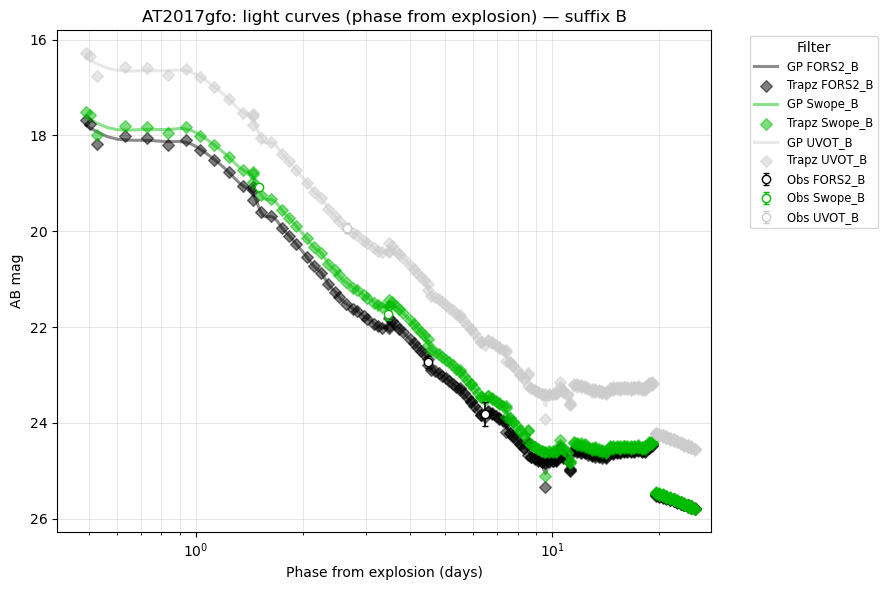

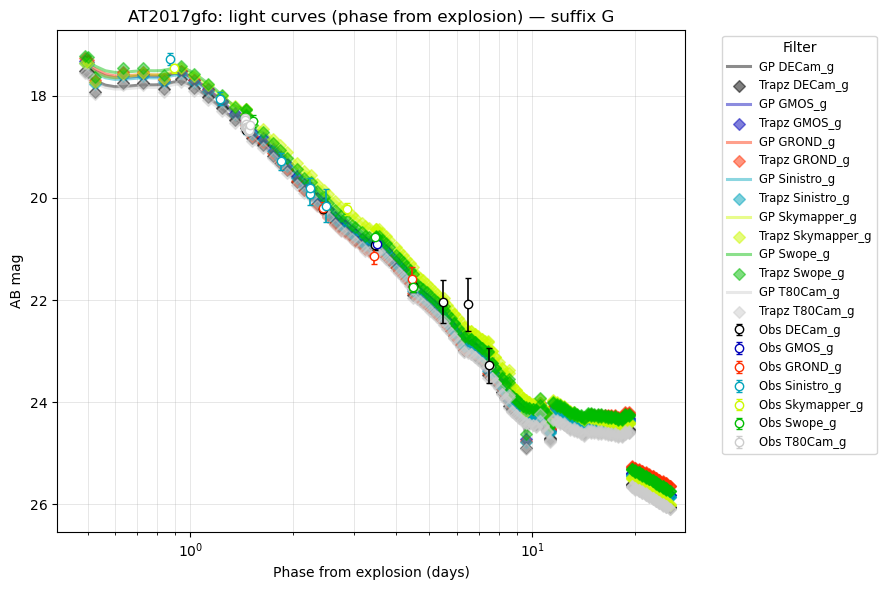

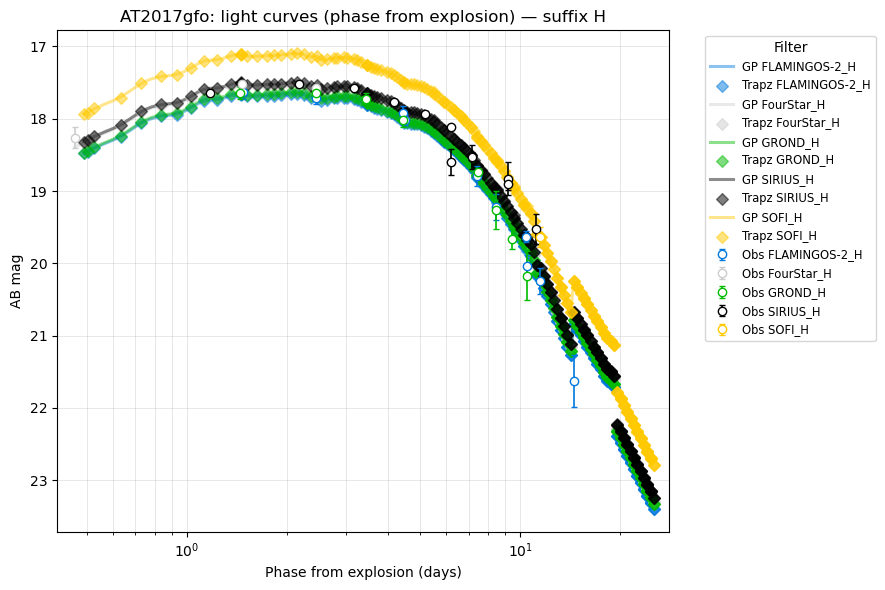

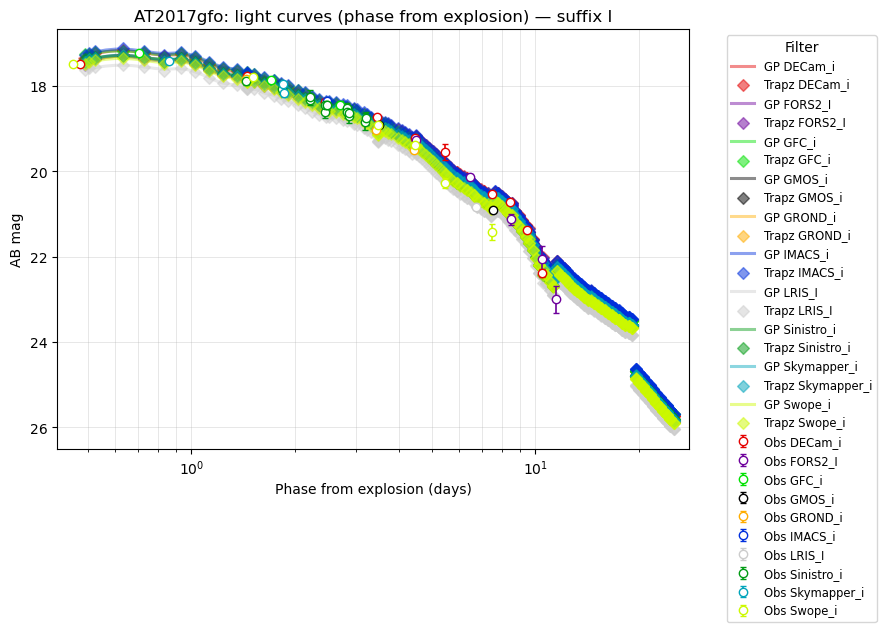

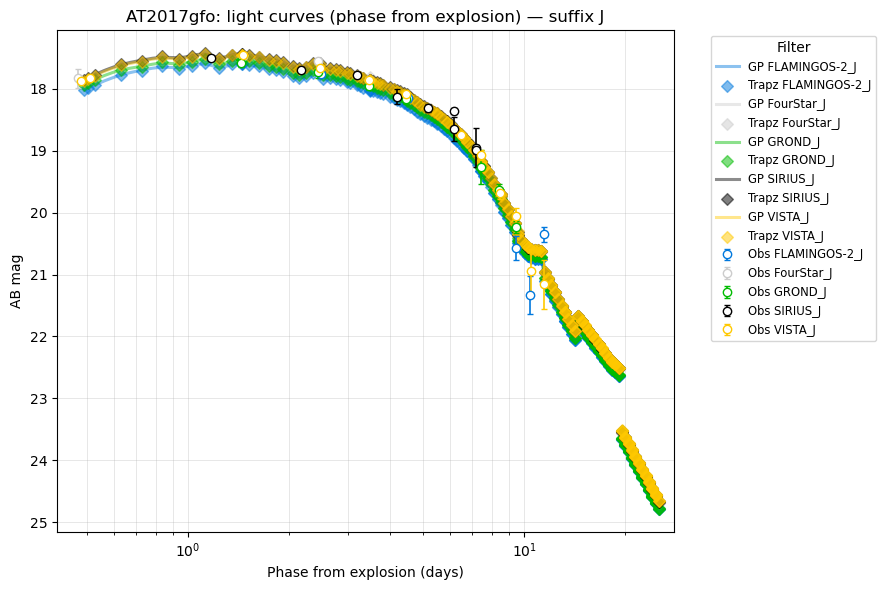

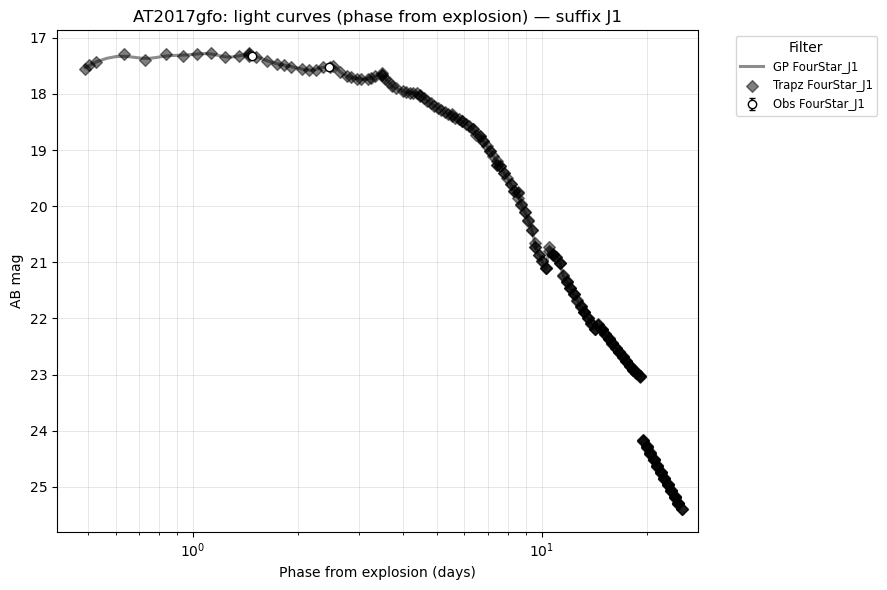

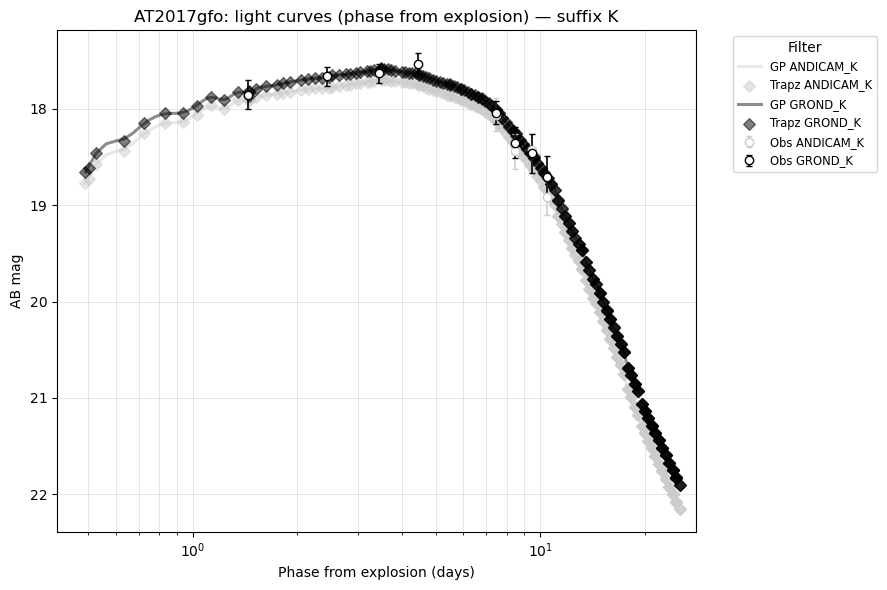

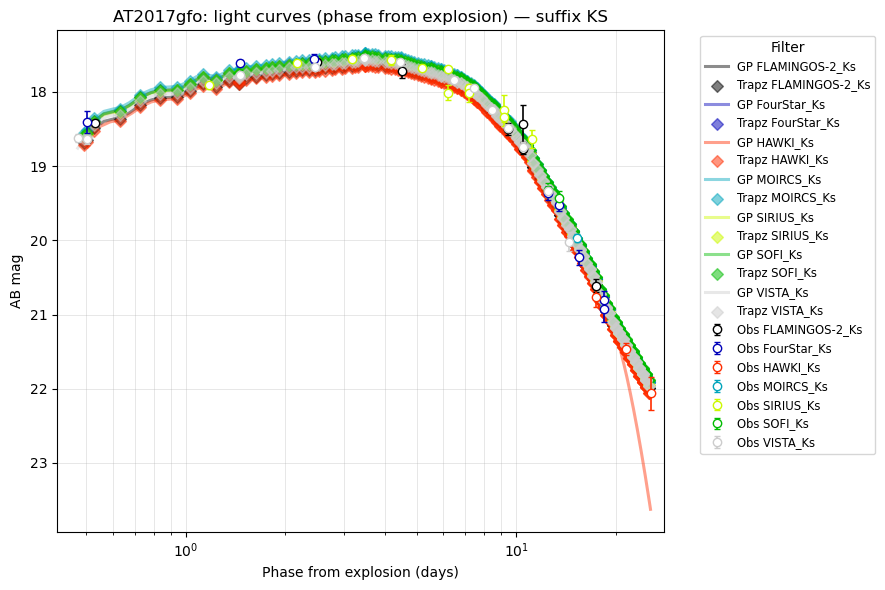

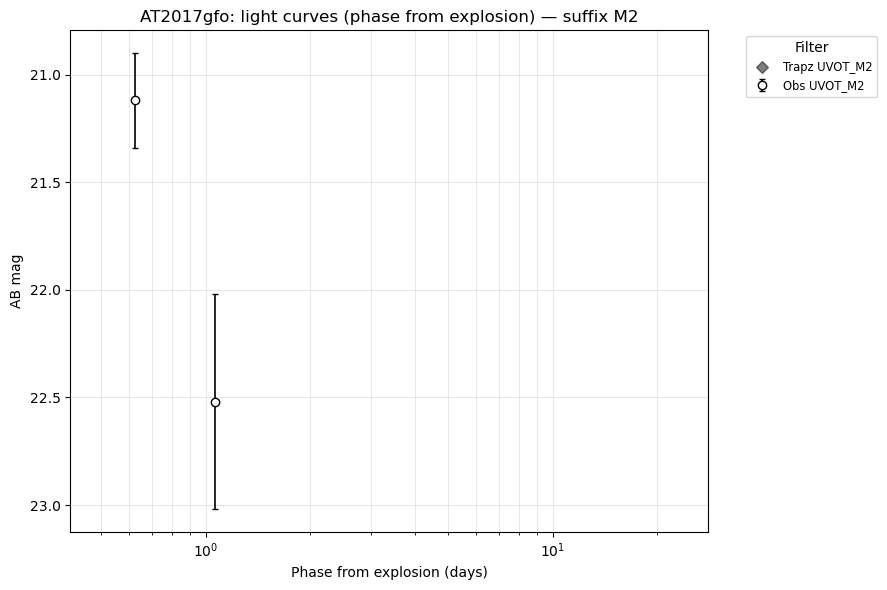

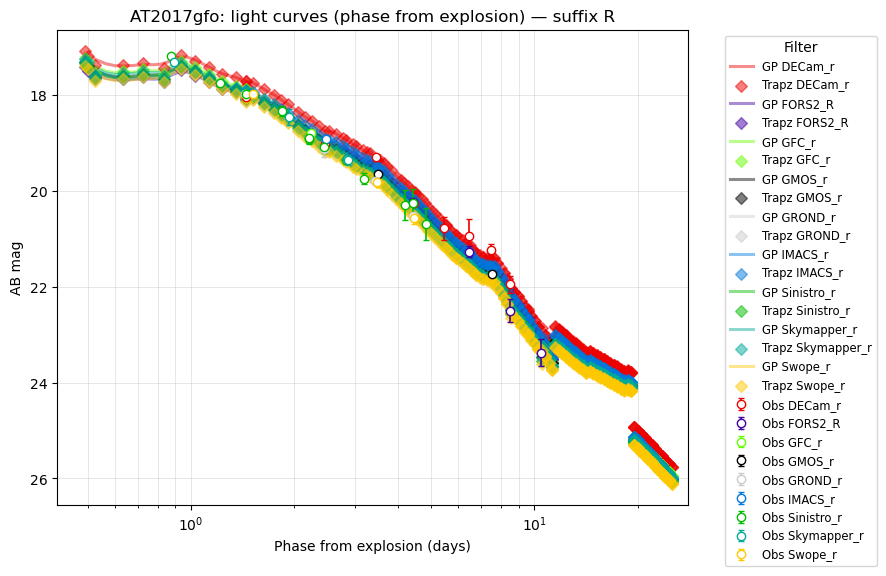

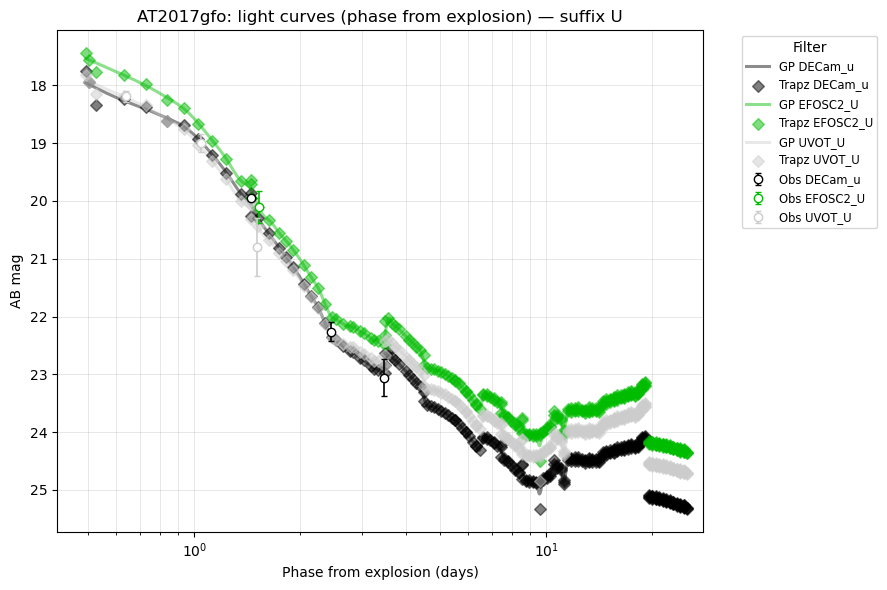

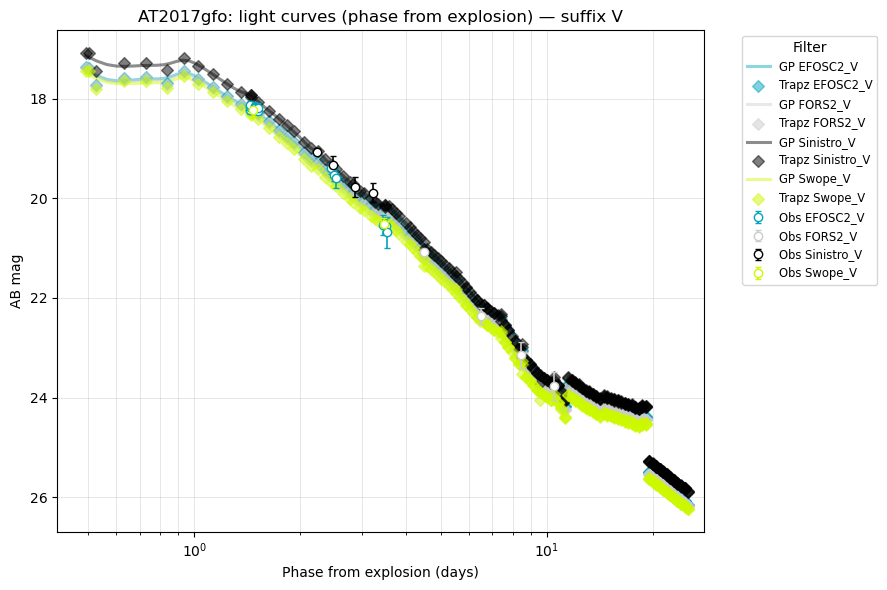

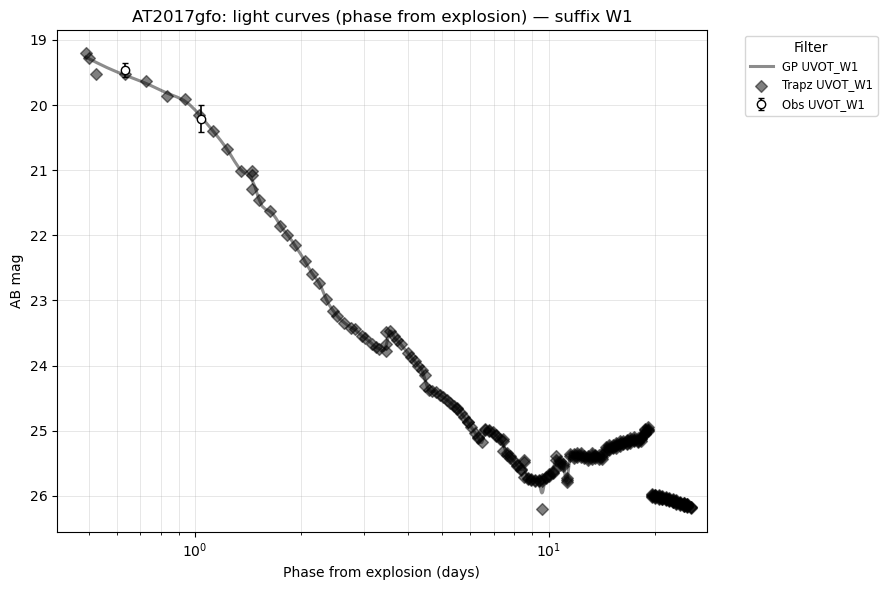

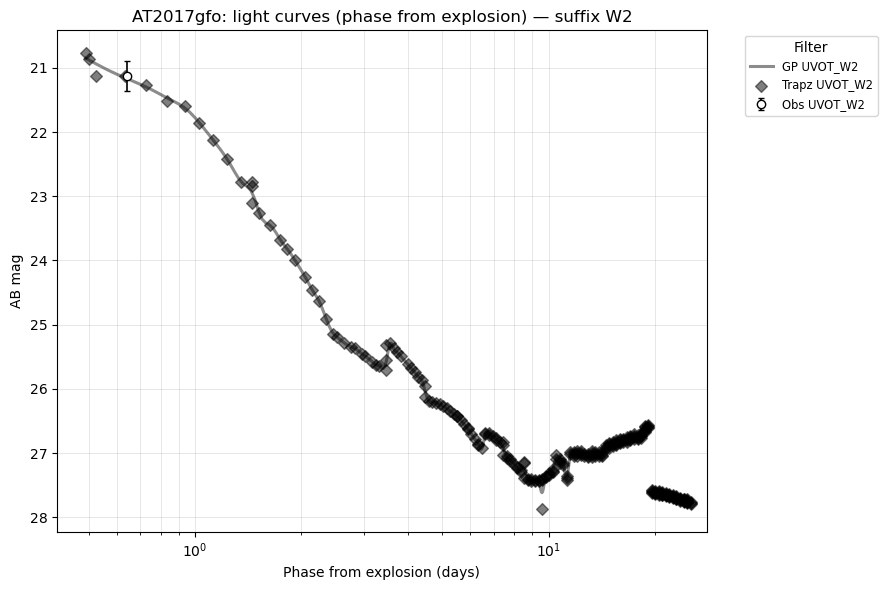

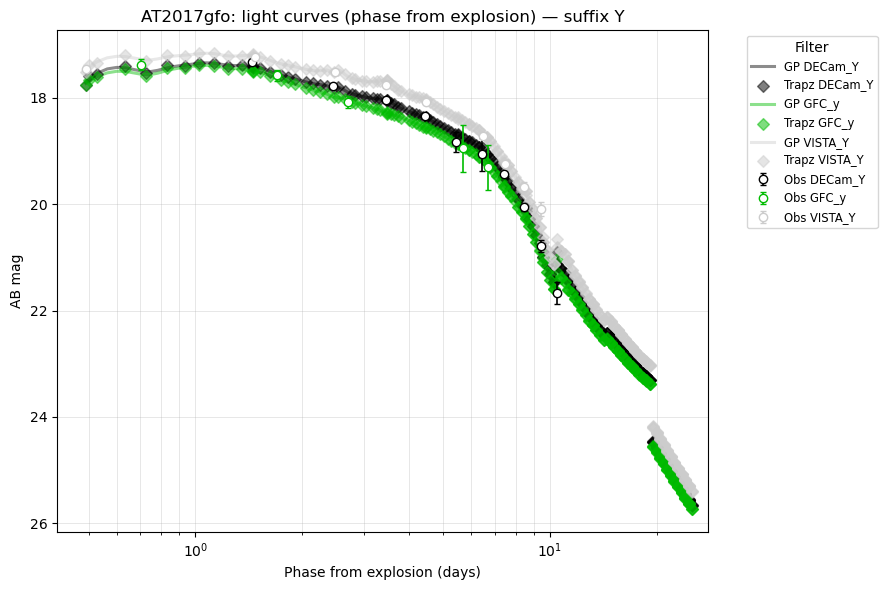

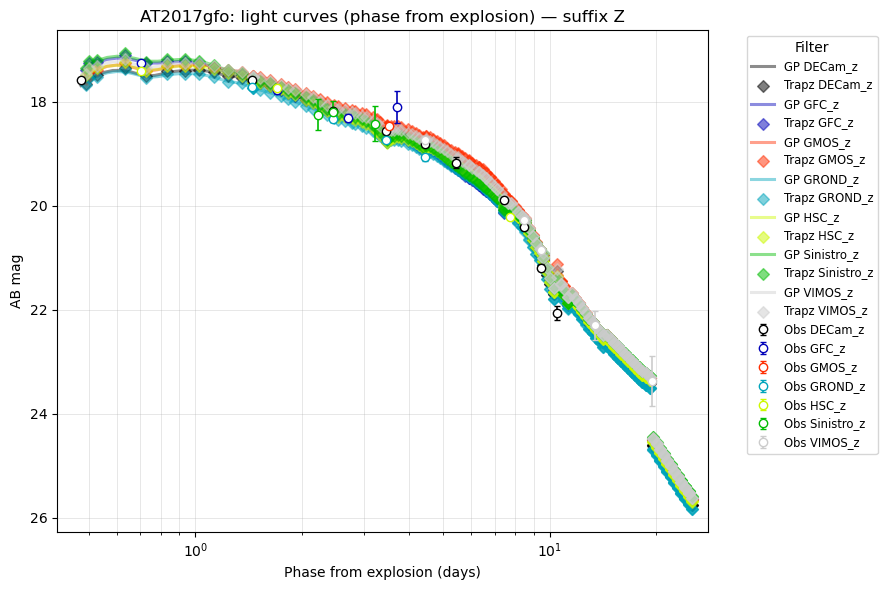

In [7]:
import os
import pickle

import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np

import pipeline_config as pconf

# ============== load cache ==============
OUTPUT_ROOT = pconf.outputs_root(COCO_PATH)
CACHE_PATH = os.path.join(OUTPUT_ROOT, SNNAME, "%s_trapz_gp_lc_cache.pkl" % SNNAME)

with open(CACHE_PATH, "rb") as f:
    cache = pickle.load(f)

if int(cache.get("version", 0)) != 1:
    raise ValueError("Unexpected cache version %r" % cache.get("version"))

t0 = float(cache["mjd0"])

# ============== plot controls (edit freely) ==============
# MODE: "panel" = one axis, all selected bands; "by_suffix" = one figure per band suffix (e.g. g, r, i)
MODE = "by_suffix"
# None = every band in the cache; or e.g. ("GROND_g", "GROND_r") to declutter
BANDS_PLOT = None

SHOW_OBS = True
SHOW_TRAPZ = True
SHOW_GP = True
# Refit GP from cached trapz in the notebook (no spectrum integration); ignores stored gp_mu/gp_sig
RECOMPUTE_GP = False
GP_N_PREDICT = 512
GP_OPTIMIZE = True
GP_LENGTH_SCALE_DAYS = 3.0
GP_LENGTH_SCALE_FACTOR = 1.0

FIGSIZE = (9, 6)
TITLE = "%s: light curves (phase from explosion)" % SNNAME
LOG_TIME_AXIS = True
LOG_TIME_LINTHRESH_DAYS = 1e-2
GP_LINE_COLOR = None
LINE_WIDTH = 2.2
OBS_MARKER_SIZE = 6.0
OBS_MARKER_EDGE_WIDTH = 1.35

# by_suffix: log-scaled positive phase like plotting-final.ipynb
SUFFIX_USE_LOG_X = True
SUFFIX_XLIM_PADDING = 0.9, 1.1  # multiply min/max positive phase
# ----------------------------------------

bands_avail = sorted(cache["bands"].keys())
if BANDS_PLOT is not None:
    wanted = set(BANDS_PLOT)
    bands_plot = [b for b in bands_avail if b in wanted]
else:
    bands_plot = list(bands_avail)

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

def _band_color(i):
    return colors[i % len(colors)]

def _gp_mag_for_band(band, d, color):
    """Return (phase_plot_mjd, mag_gp) using cache or refit."""
    mjd = d["mjd"]
    flx = d["flux"]
    fe = d["flux_err"]
    zp = float(d["zp"])
    m_tr = np.isfinite(mjd) & np.isfinite(flx) & np.isfinite(fe) & (fe > 0)
    if m_tr.sum() < 3:
        return None, None
    obs = d["obs"]
    if RECOMPUTE_GP:
        t_syn_lo = float(np.min(mjd[m_tr]))
        t_syn_hi = float(np.max(mjd[m_tr]))
        obs_mjd = obs["MJD"].values.astype(float)
        t_obs_lo = float(np.nanmin(obs_mjd))
        t_obs_hi = float(np.nanmax(obs_mjd))
        t_lo = min(t_syn_lo, t_obs_lo)
        t_hi = max(t_syn_hi, t_obs_hi)
        tgrid = np.linspace(t_lo, t_hi, int(max(8, GP_N_PREDICT)))
        mu, _sig = smooth_lightcurve_gp(
            mjd[m_tr],
            flx[m_tr],
            fe[m_tr],
            tgrid,
            optimize=GP_OPTIMIZE,
            length_scale_days=GP_LENGTH_SCALE_DAYS,
            length_scale_factor=GP_LENGTH_SCALE_FACTOR,
        )
    else:
        tgrid = d["gp_tgrid"]
        mu = d["gp_mu"]
        if tgrid is None or mu is None:
            return None, None
    mag_mu = -2.5 * np.log10(np.maximum(mu, 1e-300)) + zp
    return tgrid - t0, mag_mu


def plot_panel():
    fig, ax = plt.subplots(figsize=FIGSIZE)
    summary_bands = {}
    for i, band in enumerate(bands_plot):
        if band not in cache["bands"]:
            continue
        d = cache["bands"][band]
        color = _band_color(i)
        gp_color = color if GP_LINE_COLOR is None else GP_LINE_COLOR
        mjd = d["mjd"]
        flx = d["flux"]
        fe = d["flux_err"]
        obs = d["obs"]
        zp = float(d["zp"])
        n_zp = int(d["n_zp_matches"])
        pseudo = -2.5 * np.log10(np.maximum(flx, 1e-300)) + zp
        obs_mjd = obs["MJD"].values
        obs_mag = obs["Mag"].values
        obs_err = obs["Mag_err"].values
        obs_phase = obs_mjd - t0
        syn_phase = mjd - t0
        s_sort = np.argsort(syn_phase)
        if SHOW_GP:
            gp_x, gp_mag = _gp_mag_for_band(band, d, color)
            if gp_x is not None:
                ax.plot(
                    gp_x,
                    gp_mag,
                    "-",
                    color=gp_color,
                    lw=LINE_WIDTH,
                    alpha=0.3,
                    zorder=2,
                    label="GP %s" % band,
                )
        if SHOW_TRAPZ:
            ax.scatter(
                syn_phase[s_sort],
                pseudo[s_sort],
                color=color,
                alpha=0.5,
                zorder=4,
                marker='D',
                label="Trapz %s" % band,
            )
        if SHOW_OBS:
            ax.errorbar(
                obs_phase,
                obs_mag,
                yerr=obs_err,
                fmt="o",
                linestyle="none",
                markersize=OBS_MARKER_SIZE,
                markerfacecolor="white",
                markeredgecolor=color,
                markeredgewidth=OBS_MARKER_EDGE_WIDTH,
                ecolor=color,
                elinewidth=1.2,
                capsize=2.5,
                capthick=1.2,
                alpha=1.0,
                zorder=10,
                label="Obs %s" % band,
            )
        summary_bands[band] = {"zp": zp, "n_zp_matches": n_zp, "n_syn": int(mjd.size)}
    if LOG_TIME_AXIS:
        lt = max(float(LOG_TIME_LINTHRESH_DAYS), 1e-6)
        ax.set_xscale("symlog", linthresh=lt, linscale=1.0, base=10)
        ax.set_xlabel(
            "Phase (days since %.5f MJD; symlog, |phase| < %.3g linear)" % (t0, lt)
        )
    else:
        ax.set_xlabel("Phase (days since %.5f MJD)" % t0)
    ax.set_ylabel("AB mag")
    ax.invert_yaxis()
    ax.set_title(TITLE)
    ax.legend(loc="best", fontsize=8, ncol=2, framealpha=0.92)
    ax.grid(True, which="both", alpha=0.35, linestyle="-", linewidth=0.6)
    fig.tight_layout()
    plt.show()
    print("Plotted bands:", list(summary_bands.keys()))
    print("Summary:", summary_bands)


def plot_by_suffix():
    # Build combined phase series for global xlim (positive phase only, like plotting-final)
    phases_pos = []
    for band in bands_plot:
        if band not in cache["bands"]:
            continue
        d = cache["bands"][band]
        obs = d["obs"]
        phases_pos.append(obs["MJD"].values.astype(float) - t0)
        phases_pos.append((np.asarray(d["mjd"], dtype=float) - t0,))
    all_p = np.concatenate([np.asarray(x, dtype=float).ravel() for x in phases_pos if len(x)])
    all_p = all_p[np.isfinite(all_p) & (all_p > 0)]
    if all_p.size == 0:
        all_p = np.array([1e-2, 30.0])
    lo, hi = SUFFIX_XLIM_PADDING
    gx0 = float(np.min(all_p) * lo)
    gx1 = float(np.max(all_p) * hi)

    from collections import defaultdict
    suff_groups = defaultdict(list)
    for band in bands_plot:
        if band not in cache["bands"]:
            continue
        suff = str(band).split("_")[-1].lower()
        suff_groups[suff].append(band)

    for suff in sorted(suff_groups.keys()):
        blist = suff_groups[suff]
        fig, ax = plt.subplots(figsize=FIGSIZE)
        nb = len(blist)
        auto_colors = cm.nipy_spectral(np.linspace(0, 1, max(nb, 1)))
        rnd = np.random.RandomState(42)
        idx = np.arange(nb)
        rnd.shuffle(idx)
        for j, band in enumerate(blist):
            d = cache["bands"][band]
            color = auto_colors[idx[j % nb]]
            mjd = d["mjd"]
            flx = d["flux"]
            fe = d["flux_err"]
            obs = d["obs"]
            zp = float(d["zp"])
            pseudo = -2.5 * np.log10(np.maximum(flx, 1e-300)) + zp
            syn_phase = mjd - t0
            s_sort = np.argsort(syn_phase)
            obs_phase = obs["MJD"].values - t0
            gp_color = color if GP_LINE_COLOR is None else GP_LINE_COLOR
            if SHOW_GP:
                gp_x, gp_mag = _gp_mag_for_band(band, d, color)
                if gp_x is not None:
                    ax.plot(
                        gp_x,
                        gp_mag,
                        "-",
                        color=gp_color,
                        lw=LINE_WIDTH,
                        alpha=0.45,
                        zorder=2,
                        label="GP %s" % band,
                    )
            if SHOW_TRAPZ:
                ax.scatter(
                    syn_phase[s_sort],
                    pseudo[s_sort],
                    color=color,
                    alpha=0.5,
                    zorder=4,
                    marker='D',
                    label="Trapz %s" % band,
                )
            if SHOW_OBS:
                ax.errorbar(
                    obs_phase,
                    obs["Mag"].values,
                    yerr=obs["Mag_err"].values,
                    fmt="o",
                    linestyle="none",
                    markersize=OBS_MARKER_SIZE,
                    markerfacecolor='white',
                    markeredgecolor=color,
                    markeredgewidth=1.0,
                    ecolor=color,
                    elinewidth=1.2,
                    capsize=2.5,
                    capthick=1.2,
                    alpha=1.0,
                    zorder=10,
                    label="Obs %s" % band,
                )
        ax.set_xlim(gx0, gx1)
        if SUFFIX_USE_LOG_X:
            ax.set_xscale("log")
        ax.invert_yaxis()
        ax.set_xlabel("Phase from explosion (days)")
        ax.set_ylabel("AB mag")
        ax.set_title("%s — suffix %s" % (TITLE, suff.upper()))
        ax.legend(
            title="Filter",
            fontsize="small",
            bbox_to_anchor=(1.05, 1),
            loc="upper left",
        )
        ax.grid(True, which="both", alpha=0.35, linestyle="-", linewidth=0.6)
        fig.tight_layout()
        plt.show()


if MODE == "panel":
    plot_panel()
elif MODE == "by_suffix":
    plot_by_suffix()
else:
    raise ValueError("MODE must be 'panel' or 'by_suffix', got %r" % (MODE,))


### Optional: synphot AB mags on the native grid (same epochs)

Per epoch, compare **trapz** pseudo-magnitude (after the same empirical `zp` as above) to **synphot** `effstim('abmag')`. A rough vertical offset between the two is expected; similar **time evolution** means the trapz path is capturing the same SED trend as synphot aside from bandpass-definition differences.

In [ ]:
band_diag = "DECam_g"

lc = collect_trapz_lightcurves(
    data_dir,
    COCO_PATH,
    SNNAME,
    [band_diag],
    flux_on_disk=FINAL_FLUX_ON_DISK,
    datalc_path=DATALC_PATH,
    final_suffixes=FINAL_SUFFIXES_TO_LOAD,
    filters_parent=FILTERS_PARENT,
)
mjd_t, f_t, fe_t = lc[band_diag]["mjd"], lc[band_diag]["flux"], lc[band_diag]["flux_err"]

import pandas as pd

dfp = pd.read_csv(PHOTOMETRY_LONG_CSV)
obs = dfp[dfp["band"] == band_diag]
_mjd_fallback = float(obs["MJD"].min()) if len(obs) else float(dfp["MJD"].min())
mjd0 = float(pconf.SN_EXPLOSION_MJD.get(SNNAME, _mjd_fallback))
zp, n_zp = fit_empirical_mag_zp(
    mjd_t, f_t, obs["MJD"].values, obs["Mag"].values, dt_match_days=2.0
)
mag_trapz = -2.5 * np.log10(np.maximum(f_t, 1e-300)) + zp
print("diag band %s: zp=%s n_zp_matches=%s len(obs)=%s" % (band_diag, zp, n_zp, len(obs)))

mjd_sp, mag_sp = collect_synphot_abmag_per_epoch(
    data_dir,
    COCO_PATH,
    SNNAME,
    band_diag,
    flux_on_disk=FINAL_FLUX_ON_DISK,
    datalc_path=DATALC_PATH,
    final_suffixes=FINAL_SUFFIXES_TO_LOAD,
    filters_parent=FILTERS_PARENT,
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(mjd_t - mjd0, mag_trapz, "s", label="trapz + zp (empirical)", ms=4)
ax.plot(mjd_sp - mjd0, mag_sp, "^", label="synphot effstim (native λ)", ms=4)
ax.set_xlabel("Phase (days since %.5f MJD)" % mjd0)
ax.set_ylabel("AB mag")
ax.set_title("%s: trapz vs synphot (%s)" % (SNNAME, band_diag))
ax.legend()
ax.set_xscale('log')
ax.set_xlim(-0.1,10)
ax.set_ylim(18,24)
ax.invert_yaxis()
fig.tight_layout()
plt.show()
